Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

Load the dataset

In [2]:
data = pd.read_csv("train.csv")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11468\457307528.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("train.csv")


Data Preprocessing

In [3]:
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [5]:
data.shape

(1017209, 9)

In [6]:
data.value_counts("Open")

Open
1    844392
0    172817
Name: count, dtype: int64

In [7]:
data.value_counts("StateHoliday")

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [8]:
data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.month
data["Week"] = data["Date"].dt.isocalendar().week.astype(int)
data["Year"] = data["Date"].dt.year

In [9]:
data = data.drop(columns=["Date"])

In [10]:
# Map StateHoliday to numbers
stateholiday_map = {
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3
}
data["StateHoliday"] = data["StateHoliday"].map(stateholiday_map)

In [11]:
data.value_counts("StateHoliday")

StateHoliday
0.0    855087
1.0     20260
2.0      6690
3.0      4100
Name: count, dtype: int64

In [12]:
data.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,Week,Year
0,1,5,5263,555,1,1,0.0,1,7,31,2015
1,2,5,6064,625,1,1,0.0,1,7,31,2015
2,3,5,8314,821,1,1,0.0,1,7,31,2015
3,4,5,13995,1498,1,1,0.0,1,7,31,2015
4,5,5,4822,559,1,1,0.0,1,7,31,2015


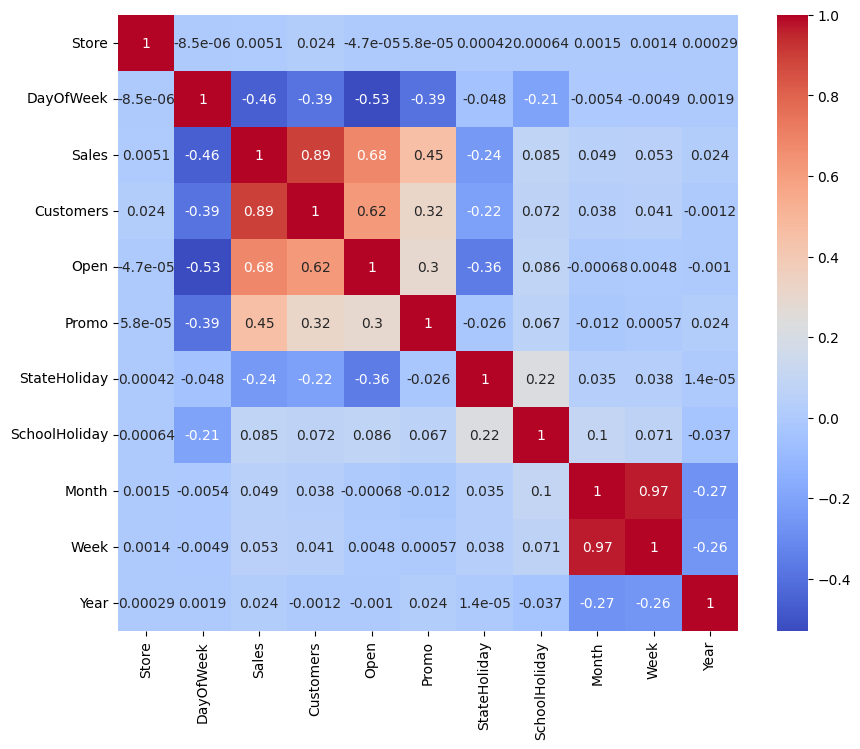

In [13]:
corr = data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.show()

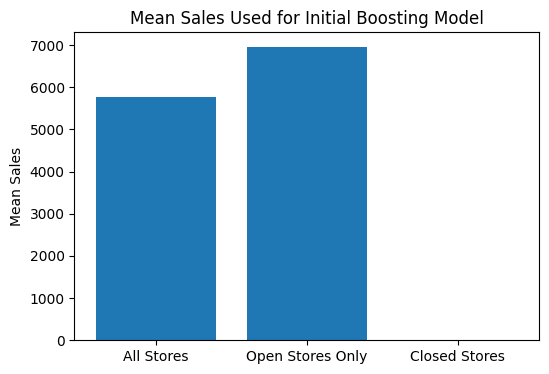

In [14]:
#See the visual difference in the effect of open and closed stores in sales

mean_all = data["Sales"].mean()
mean_open = data[data["Open"] == 1]["Sales"].mean()
mean_close = data[data["Open"] == 0]["Sales"].mean()

plt.figure(figsize=(6,4))
plt.bar(["All Stores", "Open Stores Only","Closed Stores"], [mean_all, mean_open,mean_close])
plt.ylabel("Mean Sales")
plt.title("Mean Sales Used for Initial Boosting Model")
plt.show()

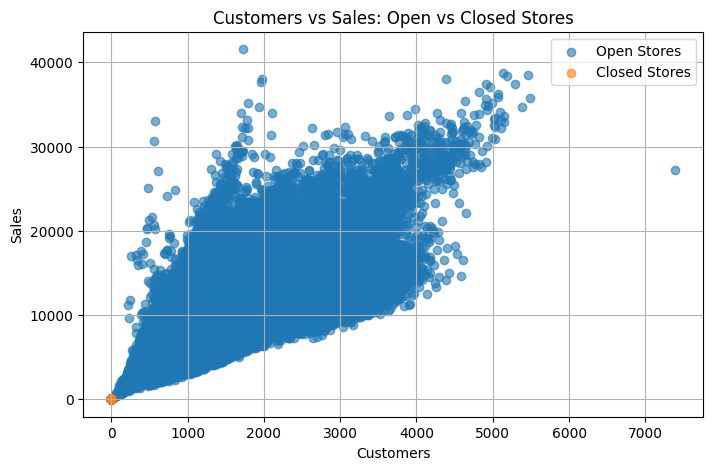

In [15]:
#Show the difference how the store status affects the sales

plt.figure(figsize=(8,5))

plt.scatter(
    data[data["Open"] == 1]["Customers"],
    data[data["Open"] == 1]["Sales"],
    alpha=0.6,
    label="Open Stores"
)

plt.scatter(
    data[data["Open"] == 0]["Customers"],
    data[data["Open"] == 0]["Sales"],
    alpha=0.6,
    label="Closed Stores"
)

plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales: Open vs Closed Stores")
plt.legend()
plt.grid(True)
plt.show()

Used only the required data for training purpose

In [16]:
# Select required columns
df = data[data["Open"] == 1]

# Remove missing values (safety)
df.dropna(inplace=True)

# # Use a smaller subset for from-scratch boosting clarity
df = df.sample(10000, random_state=42)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11468\672363215.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [17]:
df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,Week,Year
696521,432,2,9804,1580,1,0,0.0,0,10,42,2013
859804,925,3,4544,861,1,0,0.0,1,5,21,2013
782993,1049,2,5218,784,1,1,0.0,0,7,31,2013
313809,912,5,5609,743,1,1,0.0,0,10,41,2014
225450,221,6,4992,471,1,0,0.0,0,1,2,2015


In [18]:
# Split features and target
X_np = df[
    [
        "Store",
        "DayOfWeek",
        "Customers",
        "Promo",
        "Open",
        "StateHoliday",
        "SchoolHoliday",
        "Month",
        "Week",
        "Year"
    ]
].values
y_np = df["Sales"].values

X_np.shape, y_np.shape

((10000, 10), (10000,))

In [19]:
X_np

array([[4.320e+02, 2.000e+00, 1.580e+03, ..., 1.000e+01, 4.200e+01,
        2.013e+03],
       [9.250e+02, 3.000e+00, 8.610e+02, ..., 5.000e+00, 2.100e+01,
        2.013e+03],
       [1.049e+03, 2.000e+00, 7.840e+02, ..., 7.000e+00, 3.100e+01,
        2.013e+03],
       ...,
       [4.510e+02, 6.000e+00, 3.970e+02, ..., 9.000e+00, 3.800e+01,
        2.013e+03],
       [3.790e+02, 3.000e+00, 4.750e+02, ..., 4.000e+00, 1.500e+01,
        2.015e+03],
       [2.260e+02, 3.000e+00, 7.510e+02, ..., 4.000e+00, 1.600e+01,
        2.013e+03]], shape=(10000, 10))

In [20]:
y_np

array([9804, 4544, 5218, ..., 4430, 3771, 7141], shape=(10000,))

Implemented manual prediction of Gradient Boosting

In [21]:
# Initial prediction = mean of sales
initial_prediction = np.mean(y_np)

# Prediction vector
y_pred = np.full_like(y_np, initial_prediction, dtype=float)

initial_prediction

np.float64(7007.9403)

In [22]:
learning_rate = 0.1
n_estimators = 10

mse_list = []
predictions_over_time = []

for i in range(n_estimators):
    # Step 1: residuals
    residuals = y_np - y_pred

    # Step 2: weak learner
    tree = DecisionTreeRegressor(max_depth=2, random_state=42)
    tree.fit(X_np, residuals)

    # Step 3: predict residuals
    residual_pred = tree.predict(X_np)

    # Step 4: update predictions
    y_pred += learning_rate * residual_pred

    # Track error
    mse = mean_squared_error(y_np, y_pred)
    mse_list.append(mse)
    predictions_over_time.append(y_pred.copy())

print(f"Iteration {i+1}: MSE = {mse:.2f}")

Iteration 10: MSE = 4184236.44


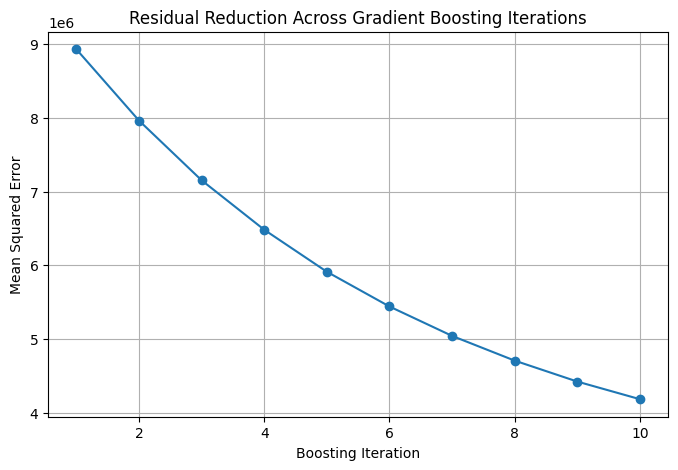

In [23]:
plt.figure(figsize=(8,5))
plt.plot(range(1, n_estimators + 1), mse_list, marker='o')
plt.xlabel("Boosting Iteration")
plt.ylabel("Mean Squared Error")
plt.title("Residual Reduction Across Gradient Boosting Iterations")
plt.grid(True)
plt.show()

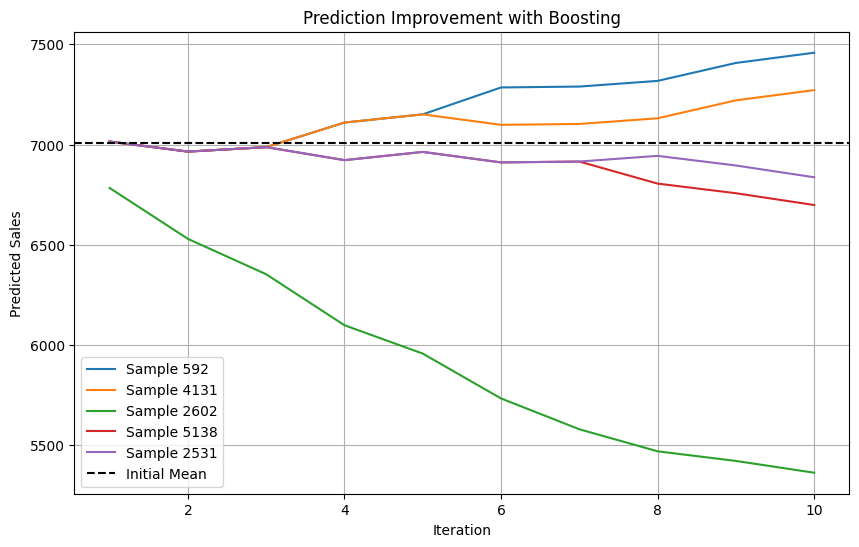

In [24]:
sample_idx = np.random.choice(len(y_np), size=5, replace=False)

plt.figure(figsize=(10,6))
for idx in sample_idx:
    preds = [pred[idx] for pred in predictions_over_time]
    plt.plot(range(1, n_estimators + 1), preds, label=f"Sample {idx}")

plt.axhline(y=initial_prediction, linestyle="--", color="black", label="Initial Mean")
plt.xlabel("Iteration")
plt.ylabel("Predicted Sales")
plt.title("Prediction Improvement with Boosting")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
X = df.drop(['Sales'],axis= 1)
y = df["Sales"]

In [26]:
X.head()

,Store,DayOfWeek,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,Week,Year
696521,432,2,1580,1,0,0.0,0,10,42,2013
859804,925,3,861,1,0,0.0,1,5,21,2013
782993,1049,2,784,1,1,0.0,0,7,31,2013
313809,912,5,743,1,1,0.0,0,10,41,2014
225450,221,6,471,1,0,0.0,0,1,2,2015


In [27]:
y.head()

696521    9804
859804    4544
782993    5218
313809    5609
225450    4992
Name: Sales, dtype: int64

In [28]:
print(X.shape,y.shape)

(10000, 10) (10000,)


In [29]:
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [30]:
n_estimators_list = [50, 100, 200]
learning_rates = [0.01, 0.1, 0.2]
max_depths = [3, 5]

Implemented Gradient Boosting using sklearn

In [31]:
results = {}

for lr in learning_rates:
    for depth in max_depths:
        model = GradientBoostingRegressor(
            n_estimators=max(n_estimators_list),
            learning_rate=lr,
            max_depth=depth,
            random_state=42
        )

        model.fit(X_train, y_train)

        train_errors = []
        val_errors = []

        for y_train_pred, y_val_pred in zip(
            model.staged_predict(X_train),
            model.staged_predict(X_test)
        ):
            train_errors.append(
                mean_squared_error(y_train, y_train_pred)
            )
            val_errors.append(
                mean_squared_error(y_test, y_val_pred)
            )

        results[(lr, depth)] = {
            "train": train_errors,
            "val": val_errors
        }

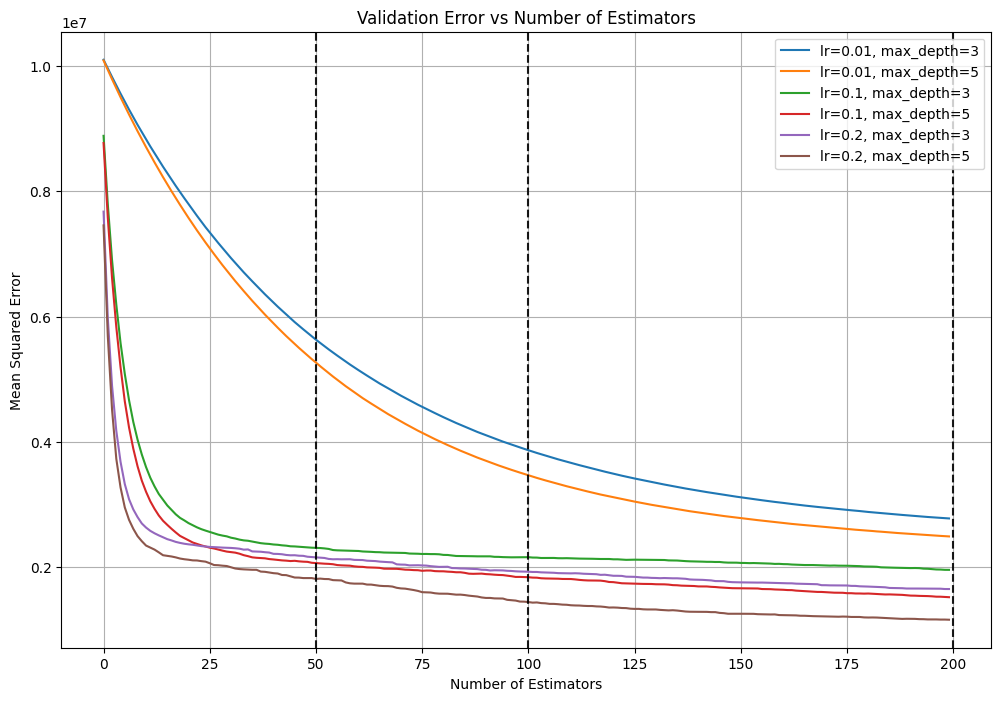

In [32]:
plt.figure(figsize=(12, 8))

# Plot validation curves
for (lr, depth), errors in results.items():
    plt.plot(
        errors["val"],
        label=f"lr={lr}, max_depth={depth}"
    )

for n in [50, 100, 200]:
    plt.axvline(
        x=n,
        linestyle="--",
        alpha=0.9,
        color="black"
    )

# Labels and formatting
plt.xlabel("Number of Estimators")
plt.ylabel("Mean Squared Error")
plt.title("Validation Error vs Number of Estimators")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
model_1 = GradientBoostingRegressor(
    learning_rate = 0.1,
    n_estimators=100,
    random_state=42
)

model_1.fit(X_train,y_train)

GradientBoostingRegressor(random_state=42)

In [34]:
pred_1 = model_1.predict(X_test)
r2_1 = r2_score(y_test,pred_1)
mse_1 = mean_squared_error(y_test,pred_1)

In [35]:
model_2 = GradientBoostingRegressor(
    learning_rate = 0.01,
    n_estimators=500,
    random_state=42
)

model_2.fit(X_train,y_train)

GradientBoostingRegressor(learning_rate=0.01, n_estimators=500, random_state=42)

In [36]:
pred_2 = model_2.predict(X_test)
r2_2 = r2_score(y_test,pred_2)
mse_2 = mean_squared_error(y_test,pred_2)

In [37]:
result_1 = pd.DataFrame({
    "Models" : ["Model_1","Model_2"],
    "mse" : [round(mse_1,4),round(mse_2,4)],
    "r2_score" : [r2_1,r2_2]
})

In [38]:
result_1

,Models,mse,r2_score
0,Model_1,2.160637e+06,0.788850
1,Model_2,2.314752e+06,0.773789


In [39]:
dt = DecisionTreeRegressor(
    max_depth=5,random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    n_jobs = -1
)

gb = GradientBoostingRegressor(
    learning_rate= 0.1,
    n_estimators=200,
    max_depth=3,
    random_state=42
)

In [40]:
models = {
    "Decision Tree" : dt,
    "Random Forest" : rf,
    "Gradient Boosting" : gb
}

final_result = []
for name,model in models.items():
    model.fit(X_train,y_train)
    final_pred = model.predict(X_test)

    final_result.append({
        "Model" : name,
        "rmse" : np.sqrt(mean_squared_error(y_test,final_pred)),
        "mae" : mean_absolute_error(y_test,final_pred),
        "r2_scores" : r2_score(y_test,final_pred)
    })

In [41]:
final_results = pd.DataFrame(final_result)
final_results

,Model,rmse,mae,r2_scores
0,Decision Tree,1627.402145,1165.771275,0.741179
1,Random Forest,1582.035277,1133.729099,0.755408
2,Gradient Boosting,1399.729634,1021.528407,0.808531


In [42]:
feature_names = X_train.columns
dt_importance = pd.Series(dt.feature_importances_, index=feature_names)
rf_importance = pd.Series(rf.feature_importances_, index=feature_names)
gb_importance = pd.Series(gb.feature_importances_, index=feature_names)

In [43]:
importance_df = pd.DataFrame({
    "Decision Tree": dt_importance,
    "Random Forest": rf_importance,
    "Gradient Boosting": gb_importance
})

importance_df

,Decision Tree,Random Forest,Gradient Boosting
Store,0.000000,0.002563,0.048164
DayOfWeek,0.005572,0.008745,0.013519
Customers,0.930950,0.927665,0.868348
Open,0.000000,0.000000,0.000000
Promo,0.056831,0.053179,0.051148
StateHoliday,0.000000,0.000189,0.000451
SchoolHoliday,0.000000,0.000010,0.000185
Month,0.002679,0.001328,0.002357
Week,0.003967,0.005741,0.014018
Year,0.000000,0.000580,0.001810


In [44]:
importance_df = importance_df.sort_values(
    by="Gradient Boosting", ascending=False
)

importance_df

,Decision Tree,Random Forest,Gradient Boosting
Customers,0.930950,0.927665,0.868348
Promo,0.056831,0.053179,0.051148
Store,0.000000,0.002563,0.048164
Week,0.003967,0.005741,0.014018
DayOfWeek,0.005572,0.008745,0.013519
Month,0.002679,0.001328,0.002357
Year,0.000000,0.000580,0.001810
StateHoliday,0.000000,0.000189,0.000451
SchoolHoliday,0.000000,0.000010,0.000185
Open,0.000000,0.000000,0.000000


In [45]:
df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,Week,Year
696521,432,2,9804,1580,1,0,0.0,0,10,42,2013
859804,925,3,4544,861,1,0,0.0,1,5,21,2013
782993,1049,2,5218,784,1,1,0.0,0,7,31,2013
313809,912,5,5609,743,1,1,0.0,0,10,41,2014
225450,221,6,4992,471,1,0,0.0,0,1,2,2015


In [51]:
new_samples = [[432, 2, 1580, 1, 0, 0.0, 0, 10, 42, 2013]]

predict = gb.predict(new_samples)
predict_rf = rf.predict(new_samples)
predict_dt = dt.predict(new_samples)
print("Predictions for new samples:")
print(predict)
print(predict_rf)
print(predict_dt)

Predictions for new samples:
[10576.37070123]
[11369.55388826]
[11163.36]


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
